# 04 · Compliance Checks, Unified Tax Features and IV Screening

1. **Gender-proxy check** — association of every feature with the applicant's gender (numeric: |correlation|;
   categorical: Cramér's V). Features above 0.5 are dropped.
2. **Address fields** — ZIP codes are dropped (too granular, potential regional proxy); districts are allowed in GBDT only.
3. **Unified tax-registry features** — the tax data comes from three vendors in succession (c → a → b). This
   section documents how the switch was diagnosed and harmonised.
4. **Model table + IV** — IV is computed on train (weeks 0–40) with equal-frequency bins; the same bins are applied to
   valid (41–50) to obtain valid IV, PSI and WOE consistency (first look at stability).

**Outputs** (`results/`): `model_data.parquet`, `04_feature_meta.parquet`, `04_iv.parquet/.csv`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs

from hcrisk.config import BOUNDS, FEAT_DIR, RES_DIR, SEED, TRAIN_END, VALID_END, savefig
from hcrisk.io import scan
from hcrisk.metrics import bin_categorical, bin_numeric, psi, woe_consistency, woe_iv

base = pl.read_parquet(RES_DIR / "base_split.parquet")
q = pl.read_parquet(RES_DIR / "03_feature_quality.parquet")
meta = q.filter(pl.col("drop_reason").is_null()).select("table", "feature", "dtype")
print("features kept after notebook 03:", meta.height)

features kept after notebook 03: 455


## 1. Gender-proxy check
Gender itself was dropped in notebook 03. Here we check whether any remaining feature is a strong proxy for it,
on a 300k sample of the development period, using the **applicant's own** gender (`sex_*__first` in `person_1`).

In [2]:
p1_cols = list(pl.read_parquet_schema(FEAT_DIR / "person_1.parquet"))
SEX_COL = next(c for c in p1_cols if c.lower().startswith("sex_") and c.endswith("__first"))
sex = pl.read_parquet(FEAT_DIR / "person_1.parquet", columns=["case_id", SEX_COL]).drop_nulls()
print(f"gender column: {SEX_COL} ->", sex[SEX_COL].value_counts().to_dicts())
top = sex[SEX_COL].mode()[0]
dev_ids = base.filter(pl.col("WEEK_NUM") <= VALID_END).select("case_id")
samp = dev_ids.sample(n=min(300_000, dev_ids.height), seed=SEED).join(
    sex.select("case_id", (pl.col(SEX_COL) == top).cast(pl.Float64).alias("_g")), on="case_id", how="inner")


def assoc_with_gender(df, c):
    """Numeric: |Pearson correlation|; categorical: Cramér's V. Both lie in [0, 1]."""
    s = df.select("_g", c).drop_nulls()
    if s.height < 1000:
        return None
    if s[c].dtype == pl.String:
        ct = s.group_by(c).agg(pl.len().alias("n"), pl.col("_g").sum().alias("n1"))
        n, p = ct["n"].sum(), s["_g"].mean()
        e1, e0 = ct["n"] * p, ct["n"] * (1 - p)
        chi2 = (((ct["n1"] - e1) ** 2) / e1 + (((ct["n"] - ct["n1"]) - e0) ** 2) / e0).sum()
        return float(np.sqrt(chi2 / n))
    x = s[c].cast(pl.Float64).to_numpy()
    return None if x.std() == 0 else abs(float(np.corrcoef(s["_g"].to_numpy(), x)[0, 1]))


assoc = []
for t in meta["table"].unique().sort():
    feats = meta.filter(pl.col("table") == t)["feature"].to_list()
    d = samp.join(pl.read_parquet(FEAT_DIR / f"{t}.parquet", columns=["case_id"] + feats), on="case_id", how="left")
    d = d.with_columns(pl.col(pl.Boolean).cast(pl.Float64))
    assoc += [{"table": t, "feature": c, "gender_assoc": assoc_with_gender(d, c)} for c in feats]
    del d; _ = gc.collect()
assoc = pl.DataFrame(assoc, schema={"table": pl.String, "feature": pl.String, "gender_assoc": pl.Float64})
meta = meta.join(assoc, on=["table", "feature"], how="left")
print("association > 0.5 (dropped):"); display(meta.filter(pl.col("gender_assoc") > 0.5))
print("association 0.3-0.5 (kept, for reference):"); display(meta.filter(pl.col("gender_assoc").is_between(0.3, 0.5)))

gender column: sex_738L__first -> [{'sex_738L__first': 'F', 'count': 952776}, {'sex_738L__first': 'M', 'count': 573883}]


association > 0.5 (dropped):


table,feature,dtype,gender_assoc
str,str,str,f64
"""tax_registry_a_1""","""name_4527232M__first""","""String""",0.78256
"""tax_registry_c_1""","""employername_160M__first""","""String""",0.756886


association 0.3-0.5 (kept, for reference):


table,feature,dtype,gender_assoc
str,str,str,f64


In the full data only the employer-name fields of the raw tax tables exceed 0.5 (≈ 0.77): employer is strongly
gender-segregated by industry — a good example of a "neutral-looking" field acting as a protected-attribute proxy.

## 2. Exclusion and usage flags
- **Raw tax tables** — replaced by the unified tax features built in section 3.
- **ZIP codes** — dropped (thousands of values, a potential regional proxy).
- **Pricing fields of this application (`eir_270L`, `interestrate_311L`)** — dropped. Under risk-based pricing the rate
  is set *after* the risk assessment, so it is either unavailable at scoring time or an echo of the previous model's
  decision. (Rates of the customer's *other* loans, e.g. `nominalrate_498L` from the credit bureau, are kept.)
- **Districts** — allowed in GBDT only (notebook 07 tests whether they help at all).

In [3]:
meta = meta.with_columns(
    pl.when(pl.col("table").str.starts_with("tax_registry")).then(pl.lit("raw tax table (replaced by unified tax features)"))
      .when(pl.col("feature").str.contains("(?i)zipcode")).then(pl.lit("ZIP code (too granular, regional proxy)"))
      .when(pl.col("feature").str.contains(r"^(eir_|interestrate_)")).then(pl.lit("pricing field (set after the risk decision)"))
      .when(pl.col("gender_assoc") > 0.5).then(pl.lit("gender proxy"))
      .otherwise(None).alias("drop_reason"),
    pl.when(pl.col("feature").str.contains("(?i)district")).then(pl.lit("gbdt_only")).otherwise(pl.lit("all")).alias("use"),
)
display(meta.group_by("drop_reason", "use").len().sort("len", descending=True))

drop_reason,use,len
str,str,u32
null,"""all""",424
"""raw tax table (replaced by uni…","""all""",14
null,"""gbdt_only""",9
"""ZIP code (too granular, region…","""all""",6
"""pricing field (set after the r…","""all""",2


## 3. Unified tax-registry features

**How the problem was found.** Notebook 03's coverage chart shows three tax tables taking over from each other:
`tax_registry_c` (weeks 0–~40) → `tax_registry_a` (~34–66) → `tax_registry_b` (~63+). A model trained on weeks 0–40
never sees vendor b, and vendor a's features vanish in OOT2.

**Investigation (kept as a record of the reasoning):**
1. *Date filter attempt.* Keeping only records dated on/before the decision removed **all** of vendor a: its date
   field is a record-write date (always 3–15 days after the decision), not a payment date. The three vendors'
   date fields mean different things, so **dates are not used at all**.
2. *Amount scale.* Raw amount medians differ by ~10× between vendors c/a and b.
3. *Cross-check on overlapping customers.* During hand-over weeks some customers have records at two vendors.
   For them, **a/c amount ratio = 1.00 exactly** (the same records, written twice during a system migration) and
   **b/a = 8.10 exactly** (a deterministic unit change).

**Resolution:** de-duplicate overlapping vendors, convert b to the a/c unit with the estimated factor, and build
vendor-agnostic features. No distributional assumption and no OOT data are needed.

In [4]:
TAX = {"c": "tax_registry_c_1", "a": "tax_registry_a_1", "b": "tax_registry_b_1"}      # in order of take-over
recs = []
for src, name in TAX.items():
    lf = scan(name)
    names = lf.collect_schema().names()
    amt, emp = [x for x in names if x.endswith("A")], [x for x in names if x.endswith("M")]
    assert len(amt) == len(emp) == 1, (name, names)
    print(f"{name}: amount = {amt[0]:22s} employer = {emp[0]}   (date field not used)")
    recs.append(lf.select("case_id", pl.col(amt[0]).cast(pl.Float64).alias("amount"),
                          pl.col(emp[0]).alias("employer"), pl.lit(src).alias("src")))
tax = pl.concat(recs).join(base.lazy().select("case_id", "WEEK_NUM"), on="case_id", how="inner").collect()

# vendor start week = first week in which >= 20% of applications have a record from that vendor
weekly_n = base.group_by("WEEK_NUM").len()
src_cov = (tax.group_by("src", "WEEK_NUM").agg(pl.col("case_id").n_unique().alias("n_cases"))
              .join(weekly_n, on="WEEK_NUM").with_columns((pl.col("n_cases") / pl.col("len")).alias("cov")))
START = {s: src_cov.filter((pl.col("src") == s) & (pl.col("cov") >= 0.2))["WEEK_NUM"].min() for s in TAX}
print("vendor start weeks:", START)
display(tax.group_by("src").agg(
    pl.col("WEEK_NUM").min().alias("first_week"), pl.col("WEEK_NUM").max().alias("last_week"),
    pl.len().alias("n_records"), pl.col("case_id").n_unique().alias("n_cases"),
    (pl.len() / pl.col("case_id").n_unique()).round(1).alias("records_per_case"),
    pl.col("amount").median().alias("amount_median")).sort("first_week"))

tax_registry_c_1: amount = pmtamount_36A          employer = employername_160M   (date field not used)
tax_registry_a_1: amount = amount_4527230A        employer = name_4527232M   (date field not used)
tax_registry_b_1: amount = amount_4917619A        employer = name_4917606M   (date field not used)


vendor start weeks: {'c': 1, 'a': 34, 'b': 66}


src,first_week,last_week,n_records,n_cases,records_per_case,amount_median
str,i64,i64,u32,u32,f64,f64
"""c""",0,40,3343800,482265,6.9,1365.454
"""a""",34,91,3275770,457934,7.2,1400.0
"""b""",62,91,1107933,150732,7.4,13130.2


### 3.1 Cross-check on customers with records at two vendors
The b→a factor is **estimated from the data** and accepted only if it is a fixed multiple
(inter-quartile range < 1% of the median); otherwise the notebook stops.

In [5]:
multi = (tax.group_by("case_id").agg(pl.col("src").unique().sort().str.join("+").alias("srcs"))
            .filter(pl.col("srcs").str.contains(r"\+")))
print(f"customers with records at more than one vendor: {multi.height:,}")
display(multi.group_by("srcs").len().sort("len", descending=True))

per = (tax.join(multi.select("case_id"), on="case_id")
          .group_by("case_id", "src").agg(pl.col("amount").median().alias("amt"), pl.len().alias("n")))
amt_w, cnt_w = per.pivot(on="src", index="case_id", values="amt"), per.pivot(on="src", index="case_id", values="n")
FACTOR = {"c": 1.0, "a": 1.0, "b": None}        # divisor that converts each vendor to the a/c unit
for x, y in [("a", "c"), ("b", "a")]:
    if x in amt_w.columns and y in amt_w.columns:
        r = amt_w.filter((pl.col(x) > 0) & (pl.col(y) > 0)).select((pl.col(x) / pl.col(y)).alias("r"))["r"]
        same = cnt_w.filter(pl.col(x).is_not_null() & pl.col(y).is_not_null()).select((pl.col(x) == pl.col(y)).alias("s"))["s"]
        q1, med, q3 = r.quantile(0.25), r.median(), r.quantile(0.75)
        print(f"{x}/{y}: amount ratio median {med:.4f}, IQR [{q1:.4f}, {q3:.4f}]; "
              f"same record count for {same.mean():.1%} of {r.len():,} customers")
        if x == "b":
            assert (q3 - q1) / med < 0.01, "b/a ratio is not a fixed multiple - do not convert, revisit the analysis"
            FACTOR["b"] = round(med, 4)
print("conversion divisors:", FACTOR)

customers with records at more than one vendor: 87,166


srcs,len
str,u32
"""a+c""",82920
"""a+b""",4246


a/c: amount ratio median 1.0000, IQR [1.0000, 1.0000]; same record count for 99.8% of 82,919 customers
b/a: amount ratio median 8.1000, IQR [8.1000, 8.1000]; same record count for 98.1% of 4,246 customers
conversion divisors: {'c': 1.0, 'a': 1.0, 'b': 8.1}


### 3.2 Convert, de-duplicate, build features

In [6]:
tax = tax.with_columns((pl.col("amount") / pl.col("src").replace_strict(FACTOR, return_dtype=pl.Float64)).alias("amt"))

# keep one vendor per customer during overlaps (priority c > a > b)
PRIORITY = {"c": 0, "a": 1, "b": 2}
keep_src = (tax.select("case_id", "src").unique()
               .with_columns(pl.col("src").replace_strict(PRIORITY, return_dtype=pl.Int8).alias("_p"))
               .sort("_p").group_by("case_id").first().select("case_id", "src"))
n_before = tax.height
tax = tax.join(keep_src, on=["case_id", "src"], how="semi")
print(f"de-duplication: {n_before:,} -> {tax.height:,} records ({n_before - tax.height:,} duplicates removed)")

tax_feat = (tax.group_by("case_id").agg(
    pl.len().cast(pl.Int32).alias("tax__cnt"),
    pl.col("employer").drop_nulls().n_unique().cast(pl.Int32).alias("tax_n_employers"),
    pl.col("amt").sum().alias("tax_amt_sum"), pl.col("amt").mean().alias("tax_amt_mean"),
    pl.col("amt").median().alias("tax_amt_median"), pl.col("amt").max().alias("tax_amt_max"),
    pl.col("amt").min().alias("tax_amt_min"),
    (pl.col("amt").std() / pl.col("amt").mean()).alias("tax_amt_cv"),
    pl.col("amount").mean().alias("_raw_amt_mean"),          # control: unconverted amount, never used in models
).with_columns(cs.float().cast(pl.Float32)))
TAX_FEATS = [x for x in tax_feat.columns if x != "case_id" and not x.startswith("_")]
tax_feat.select(["case_id"] + TAX_FEATS).write_parquet(FEAT_DIR / "tax_unified.parquet")
print(f"{len(TAX_FEATS)} unified tax features for {tax_feat.height:,} customers: {TAX_FEATS}")

de-duplication: 7,727,503 -> 7,116,089 records (611,414 duplicates removed)


8 unified tax features for 1,003,765 customers: ['tax__cnt', 'tax_n_employers', 'tax_amt_sum', 'tax_amt_mean', 'tax_amt_median', 'tax_amt_max', 'tax_amt_min', 'tax_amt_cv']


### 3.3 Distribution check across all periods (no labels used)
Panel 2 (raw) should show the cliff at vendor b's start; panel 3 (converted, same y-axis) should be flat;
panel 4 should no longer double during the c/a overlap.

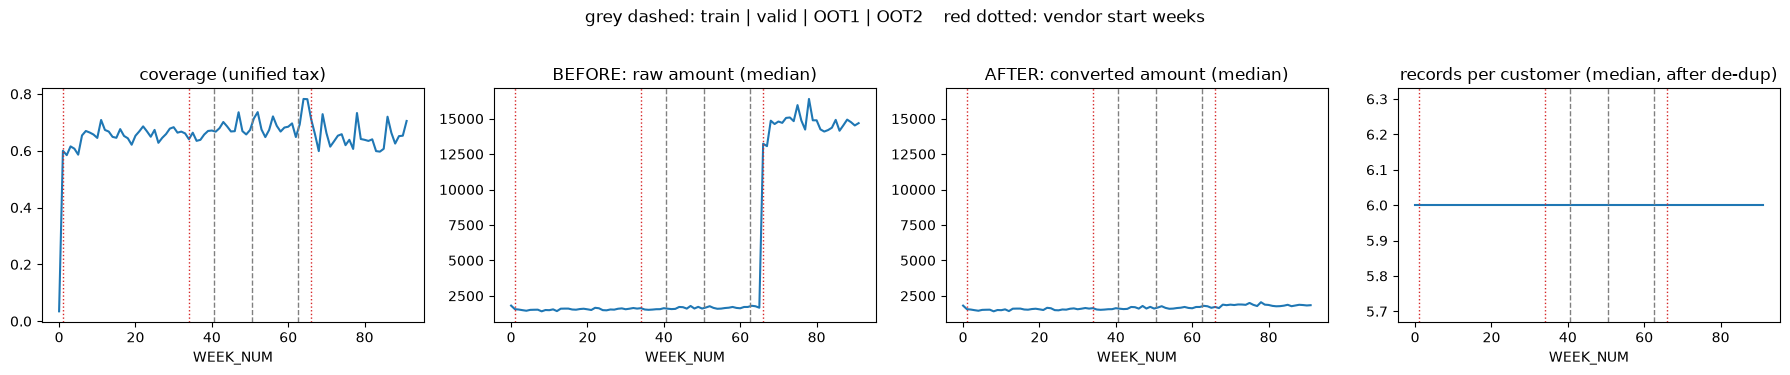

In [7]:
chk = base.select("case_id", "WEEK_NUM", "period", "target").join(tax_feat, on="case_id", how="left")
weekly = chk.group_by("WEEK_NUM").agg(
    pl.col("tax__cnt").is_not_null().mean().alias("coverage"), pl.col("_raw_amt_mean").median().alias("raw"),
    pl.col("tax_amt_mean").median().alias("converted"), pl.col("tax__cnt").median().alias("n_records")).sort("WEEK_NUM")
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, col, title in zip(axes, ["coverage", "raw", "converted", "n_records"],
                          ["coverage (unified tax)", "BEFORE: raw amount (median)", "AFTER: converted amount (median)",
                           "records per customer (median, after de-dup)"]):
    ax.plot(weekly["WEEK_NUM"], weekly[col])
    for x in BOUNDS:
        ax.axvline(x, color="grey", ls="--", lw=1)
    for w in START.values():
        if w is not None:
            ax.axvline(w, color="C3", ls=":", lw=1)
    ax.set_title(title); ax.set_xlabel("WEEK_NUM")
axes[2].set_ylim(axes[1].get_ylim())
plt.suptitle("grey dashed: train | valid | OOT1 | OOT2    red dotted: vendor start weeks", y=1.03)
plt.tight_layout(); savefig(fig, "04_tax_harmonisation"); plt.show()

### 3.4 Supervised check on the development sample only
Bins are fitted on the vendor-c era and reused in the vendor-a era (both inside weeks 0–50). Stable IV and high WOE
consistency mean the features carry the same risk meaning before and after the migration. Vendor b appears only in
OOT2, so it can only be checked without labels (3.3).

In [8]:
dev_chk = chk.filter(pl.col("WEEK_NUM") <= VALID_END)
era_c = (dev_chk["WEEK_NUM"] < START["a"]).to_numpy()
y = dev_chk["target"].to_numpy().astype(float)
rows = []
for f in TAX_FEATS + ["_raw_amt_mean"]:
    x = dev_chk[f].cast(pl.Float64).fill_null(np.nan).to_numpy()
    b_c, b_a, k = bin_numeric(x[era_c], x[~era_c])
    w_c, iv_c, s_c = woe_iv(b_c, y[era_c], k)
    w_a, iv_a, s_a = woe_iv(b_a, y[~era_c], k)
    rows.append({"feature": f, "iv_c_era": round(iv_c, 4), "iv_a_era": round(iv_a, 4),
                 "psi_c_vs_a": round(psi(s_c, s_a), 3), "woe_consistency": woe_consistency(w_c, w_a, s_c, s_a)})
display(pl.DataFrame(rows))
del chk, dev_chk; _ = gc.collect()

feature,iv_c_era,iv_a_era,psi_c_vs_a,woe_consistency
str,f64,f64,f64,f64
"""tax__cnt""",0.0426,0.0574,0.009,0.984214
"""tax_n_employers""",0.0024,0.0009,0.005,0.245626
"""tax_amt_sum""",0.0733,0.1069,0.016,0.956429
"""tax_amt_mean""",0.0361,0.053,0.03,0.932332
"""tax_amt_median""",0.0335,0.0397,0.027,0.936971
"""tax_amt_max""",0.0427,0.0696,0.025,0.957875
"""tax_amt_min""",0.0226,0.0226,0.075,0.903642
"""tax_amt_cv""",0.0011,0.0091,0.021,0.816676
"""_raw_amt_mean""",0.0361,0.053,0.03,0.932332


## 4. Depth-0 tax summary fields (`pmt*`)
`static_0` also contains tax summaries (e.g. `pmtssum_45A`, `pmtaverage_3A`). They are compared across the three
vendor eras; a median ratio > 2 or a coverage range > 0.3 marks a vendor cliff and the field is dropped (its
information is covered by the unified features). In the full data they turn out to come from vendor c only.

In [9]:
pm_cols = [x for x in pl.read_parquet_schema(FEAT_DIR / "depth0.parquet") if x.lower().startswith("pmt")]
pm_cols = [c for c in pm_cols if c in set(meta["feature"])]
era = (pl.when(pl.col("WEEK_NUM") < START["a"]).then(pl.lit("1_c_era"))
         .when(pl.col("WEEK_NUM") < (START["b"] or 999)).then(pl.lit("2_a_era"))
         .otherwise(pl.lit("3_b_era")).alias("era"))
pm = pl.read_parquet(FEAT_DIR / "depth0.parquet", columns=["case_id", "WEEK_NUM"] + pm_cols).with_columns(era)
pm_drop, rows = [], []
for col in pm_cols:
    st = pm.group_by("era").agg(pl.col(col).is_not_null().mean().alias("coverage"), pl.col(col).median().alias("median")).sort("era")
    meds = [m for m in st["median"].to_list() if m is not None and m > 0]
    ratio = max(meds) / min(meds) if len(meds) >= 2 else None
    cov_range = st["coverage"].max() - st["coverage"].min()
    cliff = (ratio is not None and ratio > 2) or cov_range > 0.3
    rows.append({"feature": col, **{f"coverage_{e}": v for e, v in zip(st["era"], st["coverage"].round(3))},
                 "median_ratio": ratio, "coverage_range": round(cov_range, 3), "vendor_cliff": cliff})
    if cliff:
        pm_drop.append(col)
display(pl.DataFrame(rows))
meta = meta.with_columns(pl.when(pl.col("feature").is_in(pm_drop))
                           .then(pl.lit("depth-0 tax summary with vendor cliff")).otherwise(pl.col("drop_reason")).alias("drop_reason"))

feature,coverage_1_c_era,coverage_2_a_era,coverage_3_b_era,median_ratio,coverage_range,vendor_cliff
str,f64,f64,f64,f64,f64,bool
"""pmtnum_254L""",0.967,0.976,0.963,1.0,0.013,false
"""pmtaverage_3A""",0.193,0.036,0.0,1.033828,0.193,false
"""pmtaverage_4527227A""",0.0,0.168,0.004,1.084453,0.168,false
"""pmtcount_4527229L""",0.0,0.168,0.004,2.166667,0.168,true
"""pmtcount_693L""",0.193,0.04,0.0,1.0,0.193,false
"""pmtscount_423L""",0.754,0.157,0.0,1.0,0.754,true
"""pmtssum_45A""",0.754,0.157,0.0,1.007597,0.754,true


## 5. Model table
Written with a streaming sink so the full table never sits in memory. Count features (`__cnt`) are filled with 0:
a missing count means "no records".

In [10]:
meta = pl.concat([meta, pl.DataFrame({"table": "tax_unified", "feature": TAX_FEATS,
                                      "dtype": [str(tax_feat[c].dtype) for c in TAX_FEATS]})
                          .with_columns(pl.lit(None, pl.Float64).alias("gender_assoc"),
                                        pl.lit(None, pl.String).alias("drop_reason"), pl.lit("all").alias("use"))],
                 how="vertical_relaxed")
use = meta.filter(pl.col("drop_reason").is_null())
assert use["feature"].n_unique() == use.height, "duplicate feature names"

lf = pl.scan_parquet(RES_DIR / "base_split.parquet").select("case_id", "WEEK_NUM", "target", "period")
for t in use["table"].unique().sort():
    feats = use.filter(pl.col("table") == t)["feature"].to_list()
    lf = lf.join(pl.scan_parquet(FEAT_DIR / f"{t}.parquet").select(["case_id"] + feats), on="case_id", how="left")
cnt_cols = [c for c in use["feature"] if c.endswith("__cnt")]
t0 = time.time()
lf.with_columns(pl.col(cnt_cols).fill_null(0), cs.float().cast(pl.Float32)).sink_parquet(RES_DIR / "model_data.parquet")
meta.write_parquet(RES_DIR / "04_feature_meta.parquet")
print(f"model_data: {len(use)} features ({len(cnt_cols)} count features filled with 0), {time.time() - t0:.0f}s")
del tax_feat; _ = gc.collect()

model_data: 438 features (9 count features filled with 0), 29s


## 6. IV screening with a first stability look
- numeric: 10 equal-frequency bins on train, missing as its own bin; categorical: categories < 0.5% merged
- these bins are for **screening only**; the scorecard uses monotonic optimal binning (notebook 06)
- `psi_train_valid`: distribution drift | `woe_consistency`: stability of the risk pattern (1 = identical) |
  `iv_valid`: discrimination decay

In [11]:
dev_lf = pl.scan_parquet(RES_DIR / "model_data.parquet").filter(pl.col("WEEK_NUM") <= VALID_END)
feats = use["feature"].to_list()
rows, t0, BATCH = [], time.time(), 40
for i in range(0, len(feats), BATCH):
    batch = feats[i:i + BATCH]
    d = dev_lf.select(["WEEK_NUM", "target"] + batch).collect()
    tr = (d["WEEK_NUM"] <= TRAIN_END).to_numpy()
    y = d["target"].to_numpy().astype(float)
    for c in batch:
        s = d[c]
        s = s.cast(pl.String) if s.dtype == pl.Boolean else s
        if s.dtype == pl.String:
            res = bin_categorical(s.filter(pl.Series(tr)), s.filter(pl.Series(~tr)))
        else:
            x = s.cast(pl.Float64).fill_null(np.nan).to_numpy()
            res = bin_numeric(x[tr], x[~tr])
        if res is None:
            continue
        b_tr, b_va, k = res
        w_tr, iv_tr, s_tr = woe_iv(b_tr, y[tr], k)
        w_va, iv_va, s_va = woe_iv(b_va, y[~tr], k)
        rows.append({"feature": c, "n_bins": int((s_tr > 0).sum()), "iv_train": iv_tr, "iv_valid": iv_va,
                     "psi_train_valid": psi(s_tr, s_va), "woe_consistency": woe_consistency(w_tr, w_va, s_tr, s_va)})
    print(f"{min(i + BATCH, len(feats)):>4}/{len(feats)}  {time.time() - t0:5.0f}s")
    del d; _ = gc.collect()
iv = pl.DataFrame(rows).join(use.select("table", "feature", "dtype", "use"), on="feature", how="left")

  40/438      2s


  80/438      5s


 120/438      8s


 160/438     11s


 200/438     13s


...

 280/438     20s


 320/438     23s


 360/438     26s


 400/438     29s


 438/438     36s


IV bands (Siddiqi): < 0.02 useless | 0.02–0.1 weak | 0.1–0.3 medium | 0.3–0.5 strong | > 0.5 suspicious (check leakage)

In [12]:
iv = iv.with_columns(
    pl.when(pl.col("iv_train") < 0.02).then(pl.lit("1 useless (<0.02)"))
      .when(pl.col("iv_train") < 0.1).then(pl.lit("2 weak (0.02-0.1)"))
      .when(pl.col("iv_train") < 0.3).then(pl.lit("3 medium (0.1-0.3)"))
      .when(pl.col("iv_train") < 0.5).then(pl.lit("4 strong (0.3-0.5)"))
      .otherwise(pl.lit("5 suspicious (>0.5)")).alias("iv_level"),
    pl.concat_str([
        pl.when(pl.col("iv_train") > 0.5).then(pl.lit("IV > 0.5, check leakage; ")),
        pl.when(pl.col("psi_train_valid") > 0.25).then(pl.lit("distribution drift (PSI > 0.25); ")),
        pl.when(pl.col("woe_consistency") < 0.5).then(pl.lit("relationship drift (WOE); ")),
        pl.when((pl.col("iv_train") >= 0.02) & (pl.col("iv_valid") < 0.5 * pl.col("iv_train"))).then(pl.lit("IV decay > 50%; ")),
    ], ignore_nulls=True).alias("flag"),
).with_columns(pl.when(pl.col("flag") == "").then(None).otherwise(pl.col("flag")).alias("flag"))

display(iv.group_by("iv_level").len().sort("iv_level"))
print("top 30 by train IV:")
display(iv.sort("iv_train", descending=True).head(30)
          .select("table", "feature", "iv_train", "iv_valid", "psi_train_valid", "woe_consistency", "flag"))
print("IV >= 0.02 with a warning flag:")
display(iv.filter((pl.col("iv_train") >= 0.02) & pl.col("flag").is_not_null()).sort("iv_train", descending=True)
          .select("table", "feature", "iv_train", "iv_valid", "psi_train_valid", "woe_consistency", "flag"))
iv.write_parquet(RES_DIR / "04_iv.parquet")
iv.write_csv(RES_DIR / "04_iv.csv", include_bom=True)
print("saved: model_data.parquet, 04_feature_meta.parquet, 04_iv.parquet/.csv")

iv_level,len
str,u32
"""1 useless (<0.02)""",189
"""2 weak (0.02-0.1)""",171
"""3 medium (0.1-0.3)""",77
"""4 strong (0.3-0.5)""",1


top 30 by train IV:


table,feature,iv_train,iv_valid,psi_train_valid,woe_consistency,flag
str,str,f64,f64,f64,f64,str
"""depth0""","""avgdpdtolclosure24_3658938P""",0.301756,0.310654,0.000168,0.989245,null
"""credit_bureau_a_2""","""pmts_dpd_1073P__mean""",0.282238,0.280403,0.019008,0.988212,null
"""credit_bureau_a_2""","""pmts_overdue_1140A__mean""",0.277393,0.26437,0.018172,0.989625,null
"""depth0""","""pctinstlsallpaidlate1d_3546856…",0.26707,0.291717,0.000257,0.992884,null
"""credit_bureau_a_1""","""dpdmax_139P__mean""",0.26607,0.261341,0.019089,0.987736,null
…,…,…,…,…,…,…
"""credit_bureau_a_1""","""overdueamountmax2_14A__mean""",0.200434,0.209426,0.018081,0.987826,null
"""credit_bureau_a_1""","""overdueamountmax_35A__mean""",0.199853,0.312259,0.617614,0.996314,"""distribution drift (PSI > 0.25…"
"""depth0""","""pctinstlsallpaidlat10d_839L""",0.199749,0.201867,0.000338,0.99099,null


IV >= 0.02 with a warning flag:


table,feature,iv_train,iv_valid,psi_train_valid,woe_consistency,flag
str,str,f64,f64,f64,f64,str
"""credit_bureau_a_2""","""pmts_dpd_303P__mean""",0.229671,0.368222,0.617625,0.998014,"""distribution drift (PSI > 0.25…"
"""credit_bureau_a_1""","""dpdmaxdateyear_596T_yrsago__me…",0.22707,0.177679,1.071862,0.951985,"""distribution drift (PSI > 0.25…"
"""credit_bureau_a_1""","""dpdmax_757P__mean""",0.226124,0.359528,0.617623,0.998182,"""distribution drift (PSI > 0.25…"
"""credit_bureau_a_1""","""numberofoverdueinstlmax_1151L_…",0.222159,0.352655,0.621006,0.997857,"""distribution drift (PSI > 0.25…"
"""credit_bureau_a_2""","""pmts_overdue_1152A__mean""",0.214984,0.339826,0.617618,0.997507,"""distribution drift (PSI > 0.25…"
…,…,…,…,…,…,…
"""credit_bureau_a_1""","""classificationofcontr_400M__nu…",0.023046,0.041092,0.623847,0.891674,"""distribution drift (PSI > 0.25…"
"""credit_bureau_a_1""","""credit_bureau_a_1__cnt""",0.022862,0.024505,0.967149,0.894029,"""distribution drift (PSI > 0.25…"
"""person_1""","""empl_industry_691L__nuniq""",0.021718,0.003135,0.005443,null,"""IV decay > 50%; """


saved: model_data.parquet, 04_feature_meta.parquet, 04_iv.parquet/.csv
